# Results Notebook

Trains all five models, saves their results for comparison and presentation.

In [28]:
# imports
import json
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from src.data.loader import load_dataset
from src.data.resampler import resample
from src.models.evaluation import (
	evaluate_model_predictions,
	save_classification_report,
	build_metrics_leaderboard
)
from src.visualization.data_visualization import (
	save_f1_chart,
	save_f1_comparison_chart,
	save_training_curves
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

### Loading and Resampling Data

In [29]:
# load the dataset

df = load_dataset()
print(f"Loaded {df.shape[0]} samples with {df.shape[1]} features.")

X = df.drop("Label", axis=1)
y = df["Label"]

Loading cleaned dataset from cache at cache/cleaned.parquet
Loaded 2522362 samples with 62 features.


In [30]:
# train test split
# 70% train, 20% test(metrics), 10% demo
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_demo, y_test, y_demo = train_test_split(X_temp, y_temp, test_size=0.333, random_state=42, stratify=y_temp)

# secondary split for models that need a validation set during training
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state=42, stratify=y_train)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Demo set: {X_demo.shape[0]} samples")
print(f"Fit set: {X_fit.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

print(f"Total samples: {X_train.shape[0] + X_test.shape[0] + X_demo.shape[0]} samples")

Training set: 1765653 samples
Test set: 504724 samples
Demo set: 251985 samples
Fit set: 1589087 samples
Validation set: 176566 samples
Total samples: 2522362 samples


In [31]:
# save demo set for later
demo_df = X_demo.copy()
demo_df["Label"] = y_demo.values
demo_df.to_parquet(RESULTS / "demo_set.parquet", index=False)

print(f"Saved demo set to results/demo_set.parquet, with {demo_df.shape[0]} samples.")

Saved demo set to results/demo_set.parquet, with 251985 samples.


In [32]:
# resample the training set for class imbalance
X_resampled, y_resampled = resample(X_fit, y_fit)
print(f"Resampled training set: {X_resampled.shape[0]} samples")

Resampled class distribution:
Label
BENIGN                        108895
Bot                           108895
DDoS                          108895
DoS GoldenEye                 108895
DoS Hulk                      108895
DoS Slowhttptest              108895
DoS slowloris                 108895
FTP-Patator                   108895
Heartbleed                    108895
Infiltration                  108895
PortScan                      108895
SSH-Patator                   108895
Web Attack - Brute Force      108895
Web Attack - Sql Injection    108895
Web Attack - XSS              108895
Resampled training set: 1633425 samples


### Model Training

In [33]:
# logistic regression training
from src.models.logistic import train_logistic_classifier, predict_labels as lr_predict

lr_artifacts = train_logistic_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	solver='newton-cholesky',
	max_iter=100,
	verbose=1
)
print("Logistic regression training complete.")

Newton iter=1
  Check Convergence
    1. max |gradient| 0.0655766971866982 <= 0.0001 False
Newton iter=2
  Check Convergence
    1. max |gradient| 0.09067582411422985 <= 0.0001 False
Newton iter=3
  Check Convergence
    1. max |gradient| 0.07009906721344158 <= 0.0001 False
Newton iter=4
  Check Convergence
    1. max |gradient| 0.0687988458660782 <= 0.0001 False
Newton iter=5
  Check Convergence
    1. max |gradient| 0.06661076008682439 <= 0.0001 False
Newton iter=6
  Check Convergence
    1. max |gradient| 0.06250362770357112 <= 0.0001 False
Newton iter=7
  Check Convergence
    1. max |gradient| 0.05825975462937809 <= 0.0001 False
Newton iter=8
  Check Convergence
    1. max |gradient| 0.0563644530479576 <= 0.0001 False
Newton iter=9
  Check Convergence
    1. max |gradient| 0.028039935168136798 <= 0.0001 False
Newton iter=10
  Check Convergence
    1. max |gradient| 0.029052571722743597 <= 0.0001 False
Newton iter=11
  Check Convergence
    1. max |gradient| 0.02067934972109734 <= 

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.814     0.898    419506
                      DDoS      0.881     0.999     0.936     25616
                  DoS Hulk      0.838     0.997     0.911     34587
             DoS GoldenEye      0.535     0.977     0.691      2059
          DoS Slowhttptest      0.390     0.979     0.557      1046
                  PortScan      0.702     0.998     0.824     18173
             DoS slowloris      0.323     0.980     0.486      1077
               FTP-Patator      0.454     0.993     0.623      1187
                       Bot      0.012     0.980     0.023       391
  Web Attack - Brute Force      0.026     0.500     0.050       294
               SSH-Patator      0.169     0.970     0.288       644
          Web Attack - XSS      0.012     0.786     0.023       131
              Infiltration      0.003     0.714     0.007         7
                Heartbleed      0.286     1.000

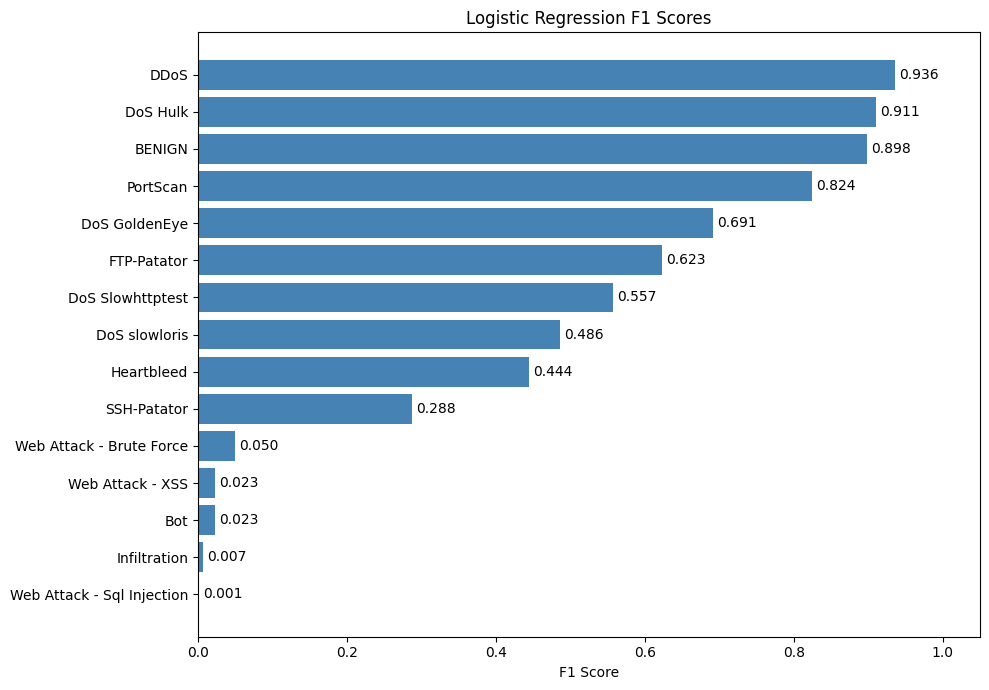

Saved results/logistic_f1_chart.png


In [34]:
# logistic regression evaluation
lr_result = evaluate_model_predictions("Logistic Regression", y_test, lr_predict(lr_artifacts, X_test))
save_classification_report(lr_result, RESULTS / "logistic_report.txt")

lr_report_dict = lr_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "logistic_report.json").write_text(json.dumps(lr_report_dict))

with open(RESULTS / "logistic_artifacts.pkl", "wb") as f:
    pickle.dump(lr_artifacts, f)

print(lr_result.classification_report_text)

save_f1_chart(
	lr_report_dict,
	title="Logistic Regression F1 Scores",
	save_path=str(RESULTS / "logistic_f1_chart.png")
)

In [35]:
# random forest training
from src.models.rf import train_rf_classifier, predict_labels as rf_predict

rf_artifacts = train_rf_classifier(
	X_resampled,
	y_resampled,
	random_state=42,
	n_estimators=200,
	max_depth=None,
)
print("Random forest training complete.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=-1)]: Done  22 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Done 172 tasks      | elapsed:   46.7s


Random forest training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   53.6s finished


[Parallel(n_jobs=14)]: Using backend ThreadingBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.1s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    0.4s
[Parallel(n_jobs=14)]: Done 200 out of 200 | elapsed:    0.5s finished


                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    419506
                      DDoS      0.999     1.000     0.999     25616
                  DoS Hulk      0.995     0.999     0.997     34587
             DoS GoldenEye      0.989     0.998     0.993      2059
          DoS Slowhttptest      0.975     0.994     0.984      1046
                  PortScan      0.989     0.998     0.994     18173
             DoS slowloris      0.977     0.986     0.982      1077
               FTP-Patator      1.000     0.999     1.000      1187
                       Bot      0.477     0.964     0.638       391
  Web Attack - Brute Force      0.743     0.687     0.714       294
               SSH-Patator      1.000     0.997     0.998       644
          Web Attack - XSS      0.350     0.534     0.423       131
              Infiltration      1.000     0.571     0.727         7
                Heartbleed      1.000     1.000

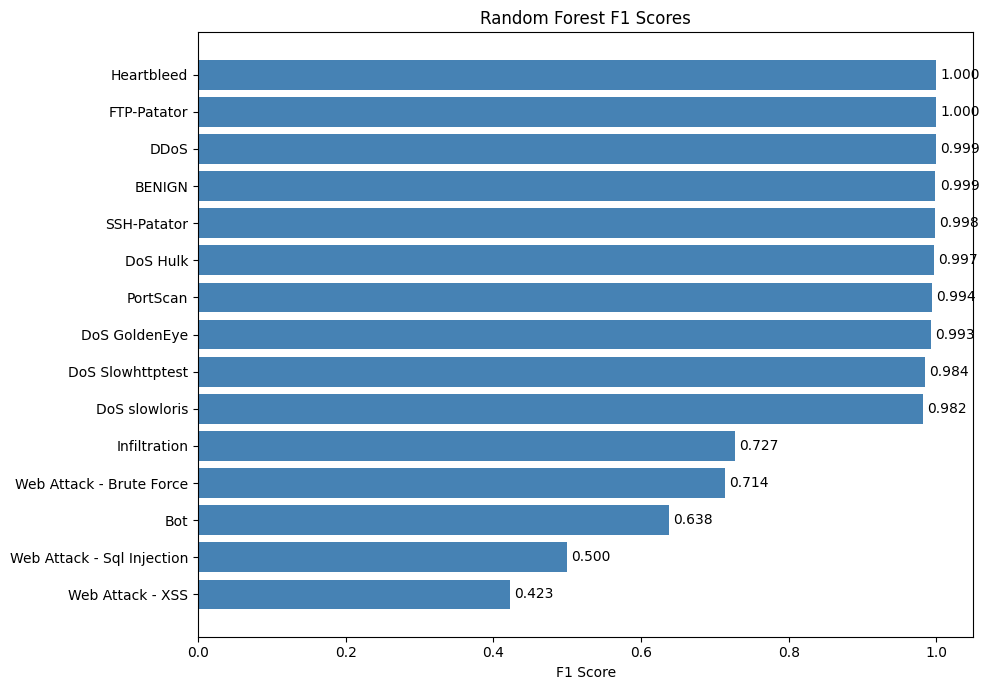

Saved results/rf_f1_chart.png


In [36]:
# rf evaluation

rf_result = evaluate_model_predictions("Random Forest", y_test, rf_predict(rf_artifacts, X_test))
save_classification_report(rf_result, RESULTS / "rf_report.txt")

rf_report_dict = rf_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "rf_report.json").write_text(json.dumps(rf_report_dict))

with open(RESULTS / "rf_artifacts.pkl", "wb") as f:
	pickle.dump(rf_artifacts, f)

print(rf_result.classification_report_text)

save_f1_chart(
	rf_report_dict,
	title="Random Forest F1 Scores",
	save_path=str(RESULTS / "rf_f1_chart.png")
)

In [37]:
# train lightgbm classifier
# Gradient boosted trees. Uses a 10% validation split from the fit set for early stopping (patience=50). Faster and more memory-efficient than RF at similar accuracy.

from src.models.lgbm import train_lightgbm_classifier, predict_labels as lgbm_predict

lgbm_artifacts = train_lightgbm_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	class_weight="balanced",
	n_estimators=500,
	early_stopping_rounds=50,
	learning_rate=0.05,
	num_leaves=63,
	random_state=42,
)
print("LightGBM training complete.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031906 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12576
[LightGBM] [Info] Number of data points in the train set: 1633425, number of used features: 59
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.708050
[LightGBM] [Info] Start training from score -2.70805

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.998     0.999    419506
                      DDoS      0.999     1.000     0.999     25616
                  DoS Hulk      0.998     0.999     0.999     34587
             DoS GoldenEye      0.987     0.998     0.993      2059
          DoS Slowhttptest      0.964     0.994     0.979      1046
                  PortScan      0.989     0.999     0.994     18173
             DoS slowloris      0.973     0.988     0.980      1077
               FTP-Patator      0.994     0.999     0.997      1187
                       Bot      0.423     0.990     0.593       391
  Web Attack - Brute Force      0.690     0.680     0.685       294
               SSH-Patator      0.992     0.997     0.995       644
          Web Attack - XSS      0.358     0.527     0.426       131
              Infiltration      0.583     1.000     0.737         7
                Heartbleed      1.000     1.000

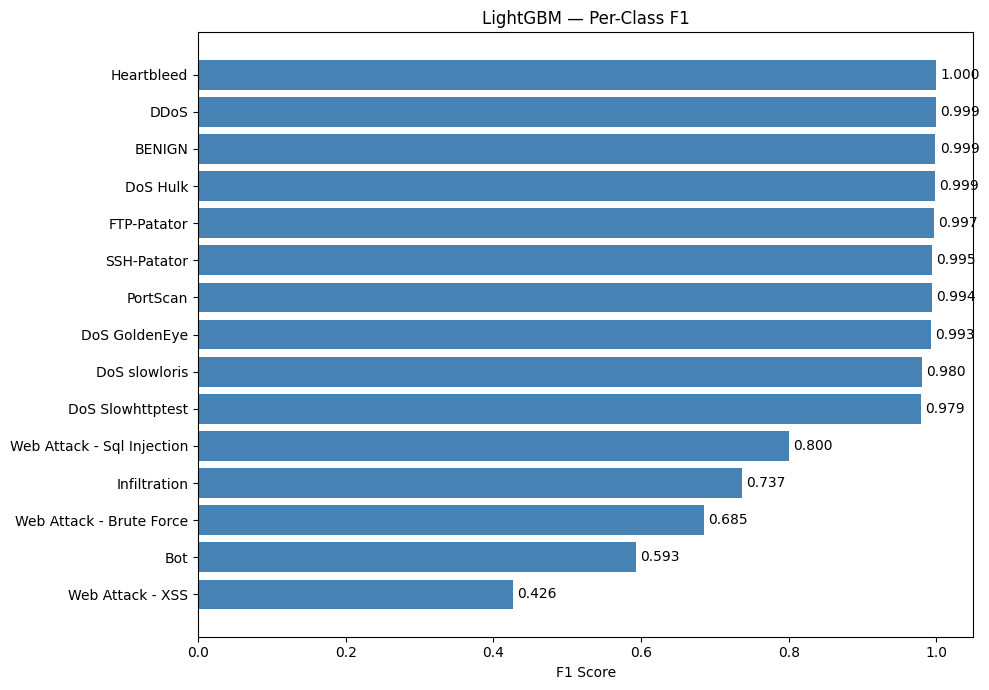

Saved results/lgbm_f1.png


In [38]:
# lightgbm evaluation
lgbm_result = evaluate_model_predictions("LightGBM", y_test, lgbm_predict(lgbm_artifacts, X_test))
save_classification_report(lgbm_result, RESULTS / "lgbm_report.txt")

lgbm_report_dict = lgbm_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "lgbm_report.json").write_text(json.dumps(lgbm_report_dict))

with open(RESULTS / "lgbm_artifacts.pkl", "wb") as f:
    pickle.dump(lgbm_artifacts, f)

print(lgbm_result.classification_report_text)

save_f1_chart(
    lgbm_report_dict,
    title="LightGBM — Per-Class F1",
    save_path=str(RESULTS / "lgbm_f1.png"),
)

In [39]:
# mlp training
# Fully-connected neural network with BatchNorm and Dropout. `StandardScaler` and `LabelEncoder` are handled internally. Uses early stopping on validation loss (patience=5). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.mlp import train_mlp_classifier, predict_labels as mlp_predict

mlp_artifacts = train_mlp_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=256,
	early_stopping_patience=10,
	_class_weight="balanced",
	learning_rate=1e-3,
	hidden_layer_sizes=(256, 128, 64),
	dropout_rate=0.3,
	random_state=42,
	verbose=1
)
print("MLP training complete.")



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 61)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,914 (234.04 KB)

 Trainable params: 58,895 (230.06 KB)

 Non-trainable params: 1,019 (3.98 KB)

None
Epoch 1/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9101 - loss: 0.2018 - val_accuracy: 0.9226 - val_loss: 0.2355
Epoch 2/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9253 - loss: 0.1441 - val_accuracy: 0.9388 - val_loss: 0.1986
Epoch 3/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9287 - loss: 0.1364 - val_accuracy: 0.9429 - val_loss: 0.1797
Epoch 4/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9307 - loss: 0.1318 - val_accuracy: 0.9522 - val_loss: 0.1559
Epoch 5/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9333 - loss: 0.1283 - val_accuracy: 0.9521 - val_loss: 0.1613
Epoch 6/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9345 - loss: 0.1262 - val_accuracy: 0.9554 - val_loss: 0.1442
Epoch 7/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9353 - loss: 0.1242 - val_accuracy: 0.9546 - val_loss: 0.1513
Epoch 8/30
6381/6381 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9347 - lo

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.952     0.975    419506
                      DDoS      0.956     0.999     0.977     25616
                  DoS Hulk      0.953     0.996     0.974     34587
             DoS GoldenEye      0.861     0.993     0.922      2059
          DoS Slowhttptest      0.775     0.989     0.869      1046
                  PortScan      0.738     0.999     0.849     18173
             DoS slowloris      0.836     0.990     0.906      1077
               FTP-Patator      0.913     0.993     0.952      1187
                       Bot      0.049     1.000     0.094       391
  Web Attack - Brute Force      0.231     0.180     0.203       294
               SSH-Patator      0.866     0.932     0.898       644
          Web Attack - XSS      0.063     0.962     0.118       131
              Infiltration      0.015     0.714     0.029         7
                Heartbleed      1.000     1.000

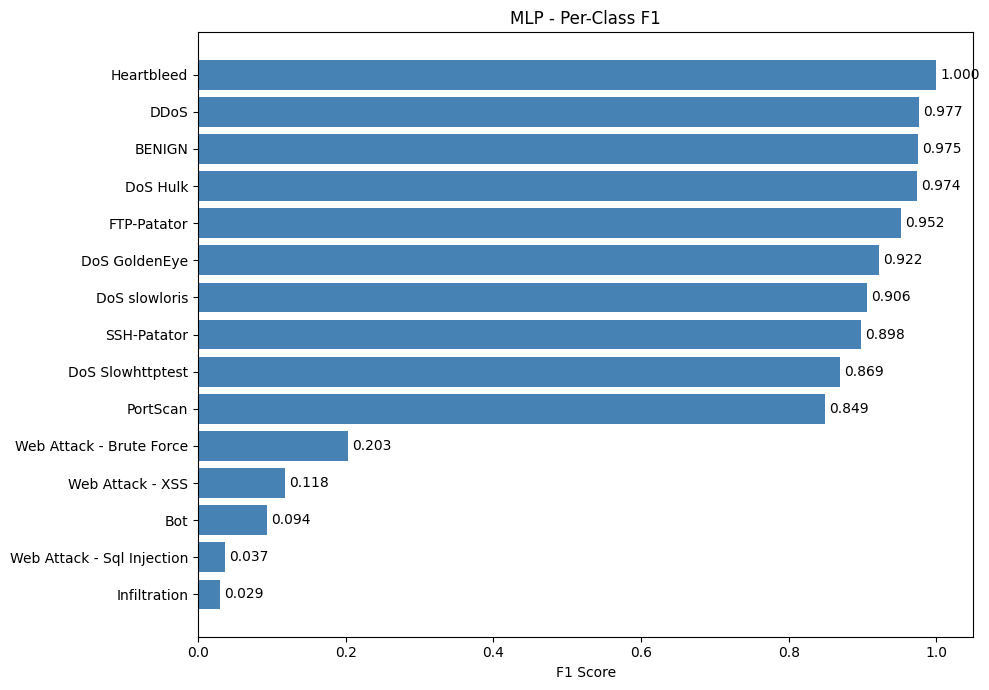

Saved results/mlp_f1.png


In [40]:
# mlp evaluation
mlp_result = evaluate_model_predictions("MLP", y_test, mlp_predict(mlp_artifacts, X_test))
save_classification_report(mlp_result, RESULTS / "mlp_report.txt")

mlp_report_dict = mlp_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "mlp_report.json").write_text(json.dumps(mlp_report_dict))

# save keras model seperately since it can't be pickled
mlp_artifacts.model.save(RESULTS / "mlp_model.keras")
with open(RESULTS / "mlp_scaler.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.scaler, f)
with open(RESULTS / "mlp_encoder.pkl", "wb") as f:
	pickle.dump(mlp_artifacts.label_encoder, f)

print(mlp_result.classification_report_text)

save_f1_chart(
	mlp_report_dict,
	title="MLP - Per-Class F1",
	save_path=str(RESULTS / "mlp_f1.png")
)

In [41]:
# cnn training
# 1D convolutional neural network. Uses early stopping on validation loss (patience=10). Model saved as .keras file; scaler and encoder saved separately for Streamlit.

from src.models.cnn import train_cnn_classifier, predict_labels as cnn_predict

cnn_artifacts = train_cnn_classifier(
	X_resampled,
	y_resampled,
	X_valid=X_val,
	y_valid=y_val,
	epochs=30,
	batch_size=128,
	early_stopping_patience=10,
	class_weight="balanced",
	learning_rate=1e-3,
	verbose=1
)
print("CNN training complete.")

Epoch 1/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.8613 - cross entropy: 0.3691 - loss: 0.3691 - val_accuracy: 0.8254 - val_cross entropy: 0.4795 - val_loss: 0.4795
Epoch 2/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.8980 - cross entropy: 0.2314 - loss: 0.2314 - val_accuracy: 0.8766 - val_cross entropy: 0.3933 - val_loss: 0.3933
Epoch 3/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.9053 - cross entropy: 0.2069 - loss: 0.2069 - val_accuracy: 0.8875 - val_cross entropy: 0.3645 - val_loss: 0.3645
Epoch 4/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.9092 - cross entropy: 0.1935 - loss: 0.1935 - val_accuracy: 0.9030 - val_cross entropy: 0.3163 - val_loss: 0.3163
Epoch 5/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.9117 - cross entropy: 0.1850 - loss: 0.1850 - val_accuracy: 0.9069 - val_cross entropy: 0.3101 - val_loss: 0.3101
Epoch 6/30
12762/12762 ━━━━━━━━━━━━━━━━━━━━ 58s 5ms/step - accuracy: 0.9134

                            precision    recall  f1-score   support

                    BENIGN      1.000     0.920     0.958    419506
                      DDoS      0.885     0.999     0.939     25616
                  DoS Hulk      0.881     0.992     0.933     34587
             DoS GoldenEye      0.651     0.994     0.787      2059
          DoS Slowhttptest      0.680     0.988     0.805      1046
                  PortScan      0.731     0.998     0.844     18173
             DoS slowloris      0.797     0.991     0.883      1077
               FTP-Patator      0.543     0.993     0.702      1187
                       Bot      0.038     1.000     0.073       391
  Web Attack - Brute Force      0.078     0.177     0.108       294
               SSH-Patator      0.382     0.930     0.542       644
          Web Attack - XSS      0.029     0.985     0.057       131
              Infiltration      0.016     0.714     0.031         7
                Heartbleed      0.667     1.000

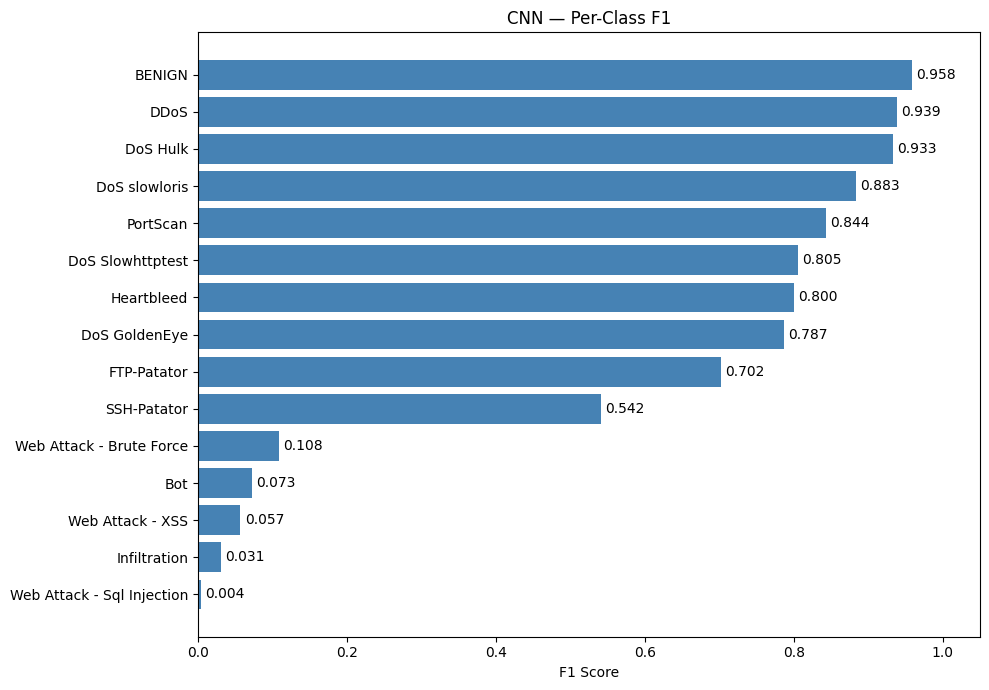

Saved results/cnn_f1.png


In [42]:
cnn_result = evaluate_model_predictions("CNN", y_test, cnn_predict(cnn_artifacts, X_test))
save_classification_report(cnn_result, RESULTS / "cnn_report.txt")

cnn_report_dict = cnn_result.classification_report_df.fillna(0).to_dict(orient="index")
(RESULTS / "cnn_report.json").write_text(json.dumps(cnn_report_dict))

cnn_artifacts.model.save(RESULTS / "cnn_model.keras")
with open(RESULTS / "cnn_scaler.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.scaler, f)
with open(RESULTS / "cnn_encoder.pkl", "wb") as f:
    pickle.dump(cnn_artifacts.label_encoder, f)

print(cnn_result.classification_report_text)

save_f1_chart(
    cnn_report_dict,
    title="CNN — Per-Class F1",
    save_path=str(RESULTS / "cnn_f1.png"),
)


### Model Comparisons